In [94]:
import pandas as pd
from pathlib import Path
import cv2
from matplotlib import pyplot as plt

In [95]:
path_ccw = "../data/raw/CCW/driving_log.csv"
path_cw = "../data/raw/CW/driving_log.csv"

In [107]:
columns = ["center", "left", "right", "steering", "throttle", "brake", "speed"]
df_ccw = pd.read_csv(path_ccw, header=None, names=columns)
df_cw = pd.read_csv(path_cw, header=None, names=columns)
df_ccw.head()

,center,left,right,steering,throttle,brake,speed
0,C:\Users\pc\Documents\GitHub\DPS920-Final\data...,C:\Users\pc\Documents\GitHub\DPS920-Final\data...,C:\Users\pc\Documents\GitHub\DPS920-Final\data...,0.0,0.0,0,0.000021
1,C:\Users\pc\Documents\GitHub\DPS920-Final\data...,C:\Users\pc\Documents\GitHub\DPS920-Final\data...,C:\Users\pc\Documents\GitHub\DPS920-Final\data...,0.0,0.0,0,0.000002
2,C:\Users\pc\Documents\GitHub\DPS920-Final\data...,C:\Users\pc\Documents\GitHub\DPS920-Final\data...,C:\Users\pc\Documents\GitHub\DPS920-Final\data...,0.0,0.0,0,0.000004
3,C:\Users\pc\Documents\GitHub\DPS920-Final\data...,C:\Users\pc\Documents\GitHub\DPS920-Final\data...,C:\Users\pc\Documents\GitHub\DPS920-Final\data...,0.0,0.0,0,0.000011
4,C:\Users\pc\Documents\GitHub\DPS920-Final\data...,C:\Users\pc\Documents\GitHub\DPS920-Final\data...,C:\Users\pc\Documents\GitHub\DPS920-Final\data...,0.0,0.0,0,0.000004


In [108]:
first_row = df_ccw[:1]

In [109]:
center_image_path = first_row["center"].values[0]
left_image_path = first_row["left"].values[0]
right_image_path = first_row["right"].values[0]

In [110]:
center_img = cv2.imread(center_image_path)
center_img = cv2.cvtColor(center_img, cv2.COLOR_BGR2RGB)
left_img = cv2.imread(left_image_path)
left_img = cv2.cvtColor(left_img, cv2.COLOR_BGR2RGB)
right_img = cv2.imread(right_image_path)
right_img = cv2.cvtColor(right_img, cv2.COLOR_BGR2RGB)

Text(0.5, 1.0, 'Right Image')

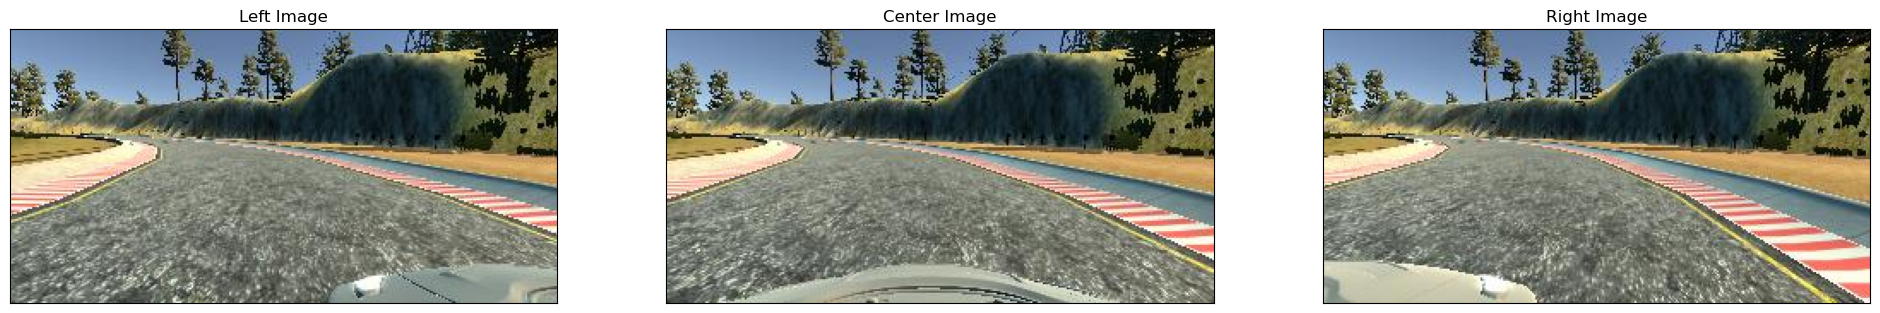

In [111]:
fig,ax = plt.subplots(1,3, figsize=(24,10))
ax[0].imshow(left_img)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_title("Left Image")
ax[1].imshow(center_img)
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_title("Center Image")
ax[2].imshow(right_img)
ax[2].set_xticks([])
ax[2].set_yticks([])
ax[2].set_title("Right Image")

### Steering Histogram

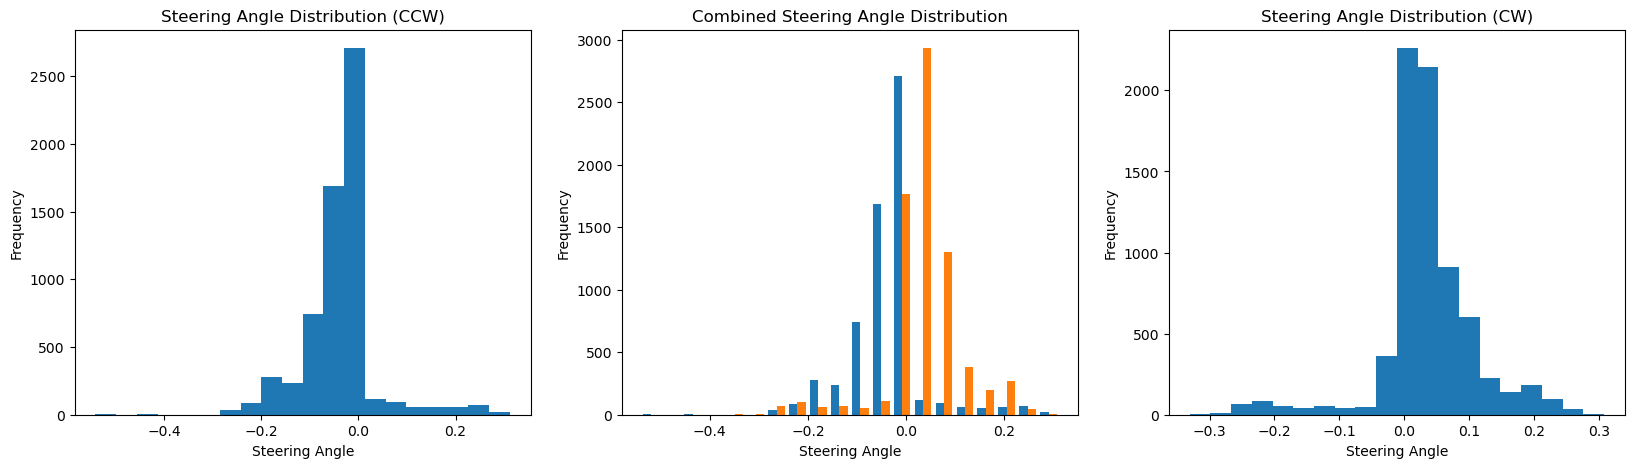

In [112]:
steering_values_ccw = df_ccw["steering"].values
steering_values_cw = df_cw["steering"].values
all_steering_values = [steering_values_ccw, steering_values_cw]

fig,axs = plt.subplots(1,3, figsize=(20,5))
axs[0].hist(steering_values_ccw, bins=20)
axs[0].set_title("Steering Angle Distribution (CCW)")
axs[0].set_xlabel("Steering Angle")
axs[0].set_ylabel("Frequency")
axs[1].hist(all_steering_values, bins=20)
axs[1].set_title("Combined Steering Angle Distribution")
axs[1].set_xlabel("Steering Angle")
axs[1].set_ylabel("Frequency")
axs[2].hist(steering_values_cw, bins=20)
axs[2].set_title("Steering Angle Distribution (CW)")
axs[2].set_xlabel("Steering Angle")
axs[2].set_ylabel("Frequency")
plt.show()

Two observations from the histograms:
1. Both distributions are heavily skewed towards zero, indicating that the majority of the steering angles are small, which is common in driving data as most of the time the vehicle is going straight.
 - This skewness can lead to a model that is biased towards predicting to just go straight, which may not be ideal for learning to handle turns effectively.

### Steering over time

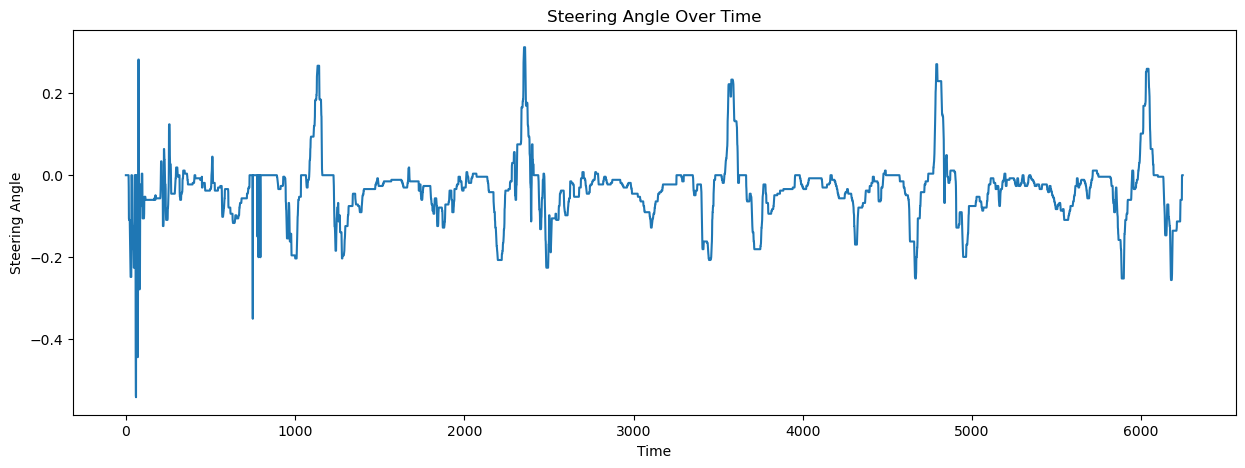

In [113]:
plt.figure(figsize=(15,5))
plt.plot(df_ccw["steering"].values)
plt.title("Steering Angle Over Time")
plt.xlabel("Time")
plt.ylabel("Steering Angle")
plt.show()